# Heart Disease Prediction and Patient Segmentation using Machine Learning

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_selection import RFE

In [ ]:
# Load dataset
df = pd.read_csv("C:/Users/1heun/Downloads/archive/heart.csv")

print(df.head())
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs    

In [ ]:
# DATA PREPROCESSING
print("Missing Values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Duplicates: 723


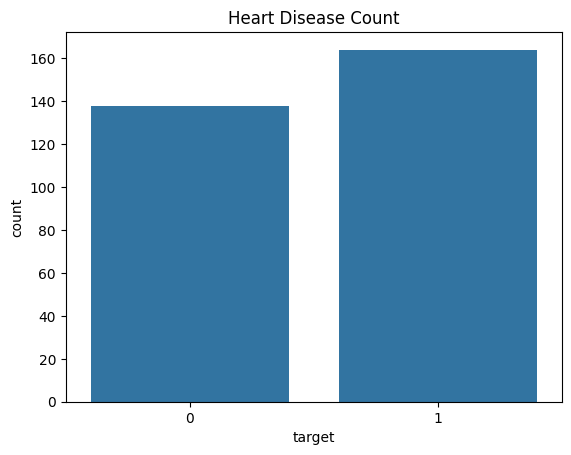

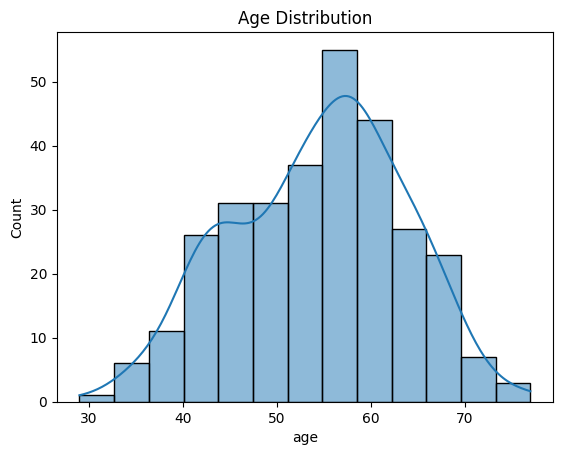

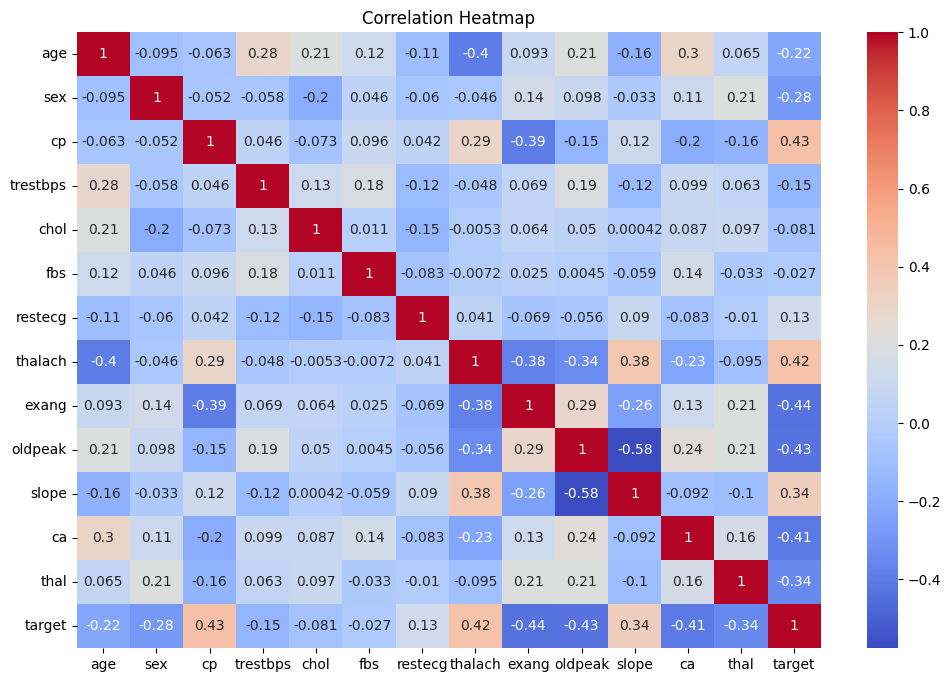

In [ ]:
# EDA
sns.countplot(x='target', data=df)
plt.title("Heart Disease Count")
plt.show()

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

SLR R2 Score: 0.019433205636784634
RMSE: 42.41128195676377
MAE: 32.77024885468831


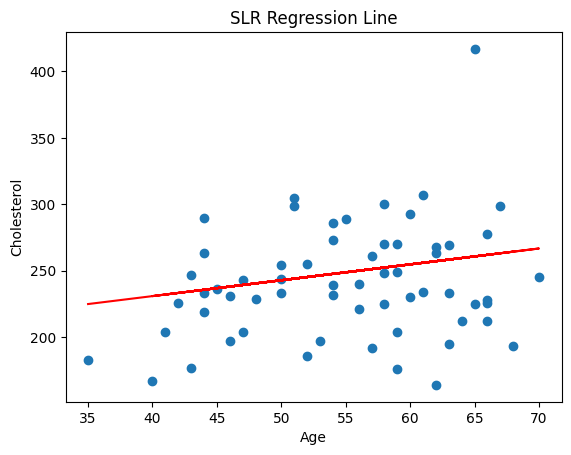

In [ ]:
# SIMPLE LINEAR REGRESSION
X = df[['age']]
y = df['chol']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

slr = LinearRegression()
slr.fit(X_train, y_train)

y_pred = slr.predict(X_test)

print("SLR R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("SLR Regression Line")
plt.show()

In [ ]:
# MULTIPLE LINEAR REGRESSION
features = ['age', 'trestbps', 'thalach', 'oldpeak']

X = df[features]
y = df['chol']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred = mlr.predict(X_test)

print("MLR R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

MLR R2 Score: -0.08031402583300662
RMSE: 44.516172448167474
MAE: 35.1170412930908


In [ ]:
# RFE
selector = RFE(LinearRegression(), n_features_to_select=2)
selector.fit(X, y)

print("Selected Features:", X.columns[selector.support_])

Selected Features: Index(['age', 'oldpeak'], dtype='str')


In [ ]:
# LOGISTIC REGRESSION
features = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6885245901639344
Precision: 0.631578947368421
Recall: 0.8275862068965517
F1 Score: 0.7164179104477612
Confusion Matrix:
 [[18 14]
 [ 5 24]]


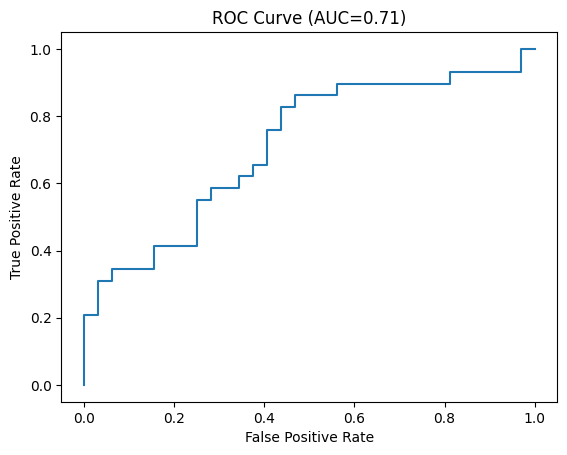

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC={auc:.2f})")
plt.show()


In [ ]:
# K-MEANS CLUSTERING
cluster_features = ['age', 'chol', 'trestbps', 'thalach']

X = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

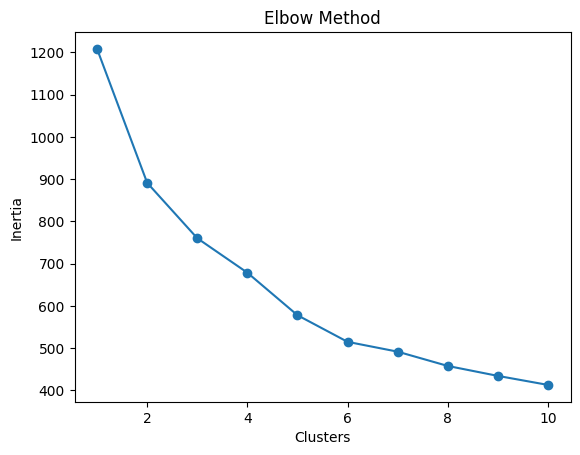

In [ ]:
# Elbow Method
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

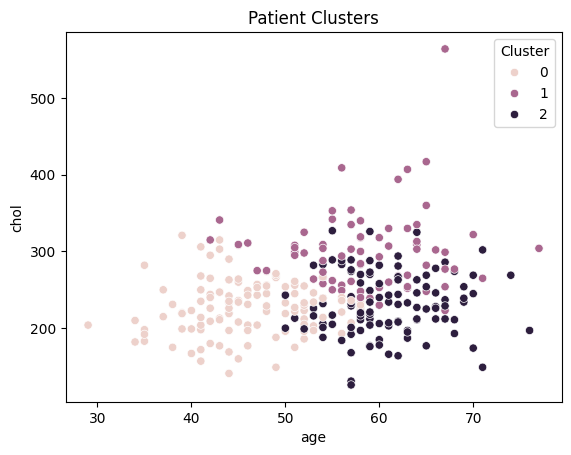

In [ ]:
# Final KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(
    x=df['age'],
    y=df['chol'],
    hue=df['Cluster']
)

plt.title("Patient Clusters")
plt.show()

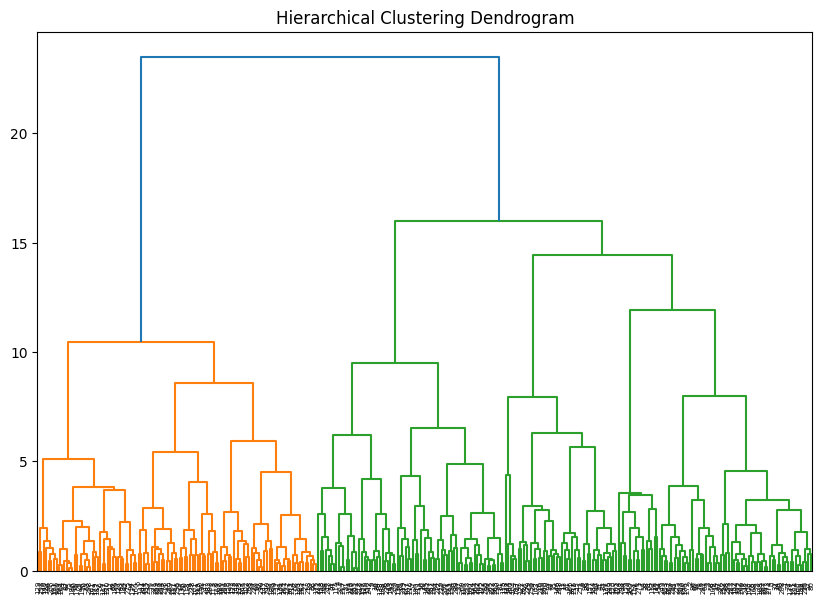

PROJECT COMPLETED SUCCESSFULLY


In [ ]:
# HIERARCHICAL CLUSTERING
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

print("PROJECT COMPLETED SUCCESSFULLY")